In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

import json
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
# Load the main.config.json file 

def load_main_config():
    with open("../config/main.config.json", "r") as f:
        return json.load(f)

main_config = load_main_config()
main_config

{'active_version': 'v1',
 'paths': {'model': 'models/v1/model_bundle.pkl',
  'thresholds': 'config/v1/threshold-config.json',
  'data_config': 'config/v1/data-config.json'},
 'data': {'filename': 'synthetic_crudop_logs.csv'},
 's3': {'bucket': 'crud-sla', 'prefix': 'anomaly-detection'},
 'flags': {'upload_to_s3': False, 'download_from_s3': False}}

In [3]:
def get_path(key, config):
    return "../" + config["paths"][key]

data_config_path = get_path("data_config", main_config)

with open(data_config_path, "r") as f:
    data_config = json.load(f)

data_config.keys()

dict_keys(['_meta', 'randomness', 'commands_meta', 'commands', 'hourly_rules_meta', 'hourly_rules'])

In [4]:
np.random.seed(42)

def add_noise(value, pct):
    return value * (1 + np.random.uniform(-pct, pct))

def random_in_range(low, high, pct):
    base = np.random.uniform(low, high)
    return add_noise(base, pct)

def apply_hourly_rules(cmd, hour, values, hourly_rules):
    hour_str = str(hour)

    if hour_str in hourly_rules and cmd in hourly_rules[hour_str]:
        rules = hourly_rules[hour_str][cmd]

        for key, multiplier in rules.items():
            field = key.replace("_multiplier", "")
            if field in values:
                values[field] *= multiplier

    return values

In [5]:
def generate_data(start_date, hours, config):

    RANDOMNESS = config["randomness"]
    commands_config = config["commands"]
    hourly_rules = config["hourly_rules"]

    data = []
    current = start_date

    for _ in range(hours):
        hour = current.hour

        for cmd, cfg in commands_config.items():

            values = {
                "success_vol": add_noise(cfg["success_vol"], RANDOMNESS),
                "fail_vol": add_noise(cfg["fail_vol"], RANDOMNESS),
                "success_rt": random_in_range(*cfg["success_rt"], RANDOMNESS),
                "fail_rt": random_in_range(*cfg["fail_rt"], RANDOMNESS)
            }

            values = apply_hourly_rules(cmd, hour, values, hourly_rules)

            data.append({
                "timestamp": current,
                "operation": cmd,   # changed from command → operation
                "success_vol": int(values["success_vol"]),
                "success_rt_avg": round(values["success_rt"], 3),
                "fail_vol": int(values["fail_vol"]),
                "fail_rt_avg": round(values["fail_rt"], 3)
            })

        current += timedelta(hours=1)

    return pd.DataFrame(data)

In [6]:
df = generate_data(
    start_date=datetime(2025, 1, 1),
    hours=24 * 120,   
    config=data_config
)

df.head(50)

,timestamp,operation,success_vol,success_rt_avg,fail_vol,fail_rt_avg
0,2025-01-01 00:00:00,GET,78996,12.441,418,2.383
1,2025-01-01 00:00:00,POST,9558,32.689,1554,10.685
2,2025-01-01 00:00:00,PUT,15498,34.332,2913,19.612
3,2025-01-01 00:00:00,DELETE,6952,23.306,1762,12.749
4,2025-01-01 01:00:00,GET,79648,7.007,411,3.606
5,2025-01-01 01:00:00,POST,10107,22.257,1450,20.263
6,2025-01-01 01:00:00,PUT,14706,50.225,2879,16.822
7,2025-01-01 01:00:00,DELETE,6674,19.189,1873,13.143
8,2025-01-01 02:00:00,GET,80373,15.100,387,5.009
9,2025-01-01 02:00:00,POST,10097,21.108,1563,10.270


In [7]:
df.describe()

,timestamp,success_vol,success_rt_avg,fail_vol,fail_rt_avg
count,11520,11520.000000,11520.000000,11520.000000,11520.000000
mean,2025-03-01 23:30:00,31770.757899,27.050522,1692.663455,13.989913
min,2025-01-01 00:00:00,6650.000000,4.762000,380.000000,1.917000
25%,2025-01-30 23:45:00,9545.000000,15.054000,1173.500000,8.469750
50%,2025-03-01 23:30:00,14450.000000,25.710500,1642.000000,14.880500
75%,2025-03-31 23:15:00,42225.000000,35.878500,2863.000000,18.762250
max,2025-04-30 23:00:00,335876.000000,86.914000,3773.000000,31.397000
std,NaN,43318.017723,14.342389,946.976023,7.425870


In [8]:
df.groupby("operation")["success_vol"].mean()

operation
DELETE     7880.590278
GET       91695.542708
POST      10618.134028
PUT       16888.764583
Name: success_vol, dtype: float64

<Axes: xlabel='timestamp'>

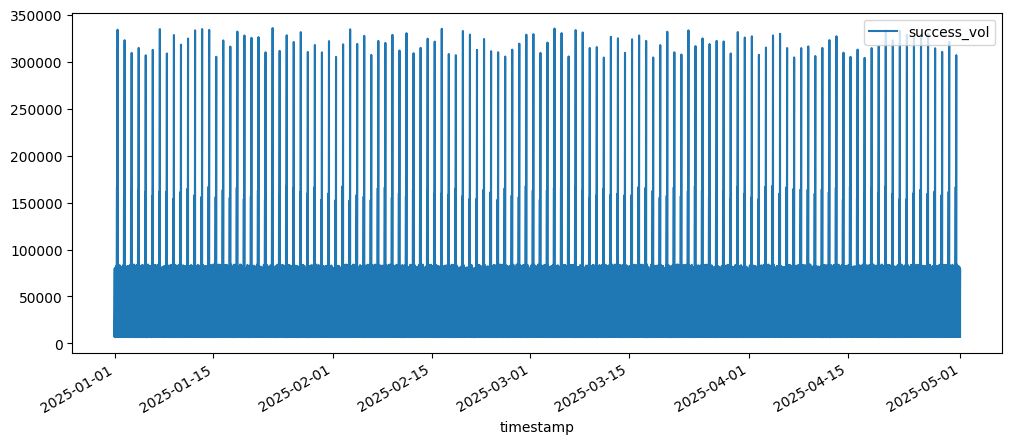

In [9]:
df.plot(x="timestamp", y="success_vol", figsize=(12,5))

In [10]:
output_path = "../data/raw/synthetic_crudop_logs.csv"
df.to_csv(output_path, index=False)

print(f"Saved to {output_path}")

Saved to ../data/raw/synthetic_crudop_logs.csv


<Axes: xlabel='hour'>

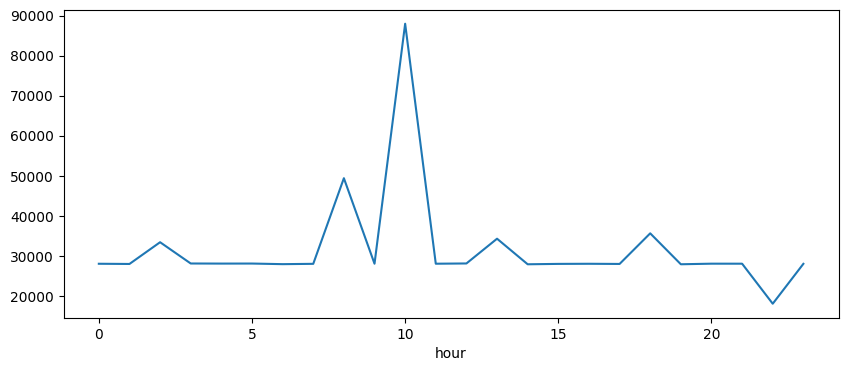

In [11]:
df["hour"] = df["timestamp"].dt.hour
df.groupby("hour")["success_vol"].mean().plot(figsize=(10,4))